# Analysis of data scraped from tagesschau.de and berliner-kurier.de

# 1. Data import and EDA

In [2]:
import pandas as pd

In [187]:
# tagesschau data from each day
tagesschau_5june_df = pd.read_csv('tagesschau_5june.csv')
tagesschau_6june_df = pd.read_csv('tagesschau_6june.csv')
tagesschau_7june_df = pd.read_csv('tagesschau_7june.csv')

In [188]:
# berliner kurier data from each day
kurier_5june_df = pd.read_csv('kurier_5june.csv')
kurier_6june_df = pd.read_csv('kurier_6june.csv')
kurier_7june_df = pd.read_csv('kurier_7june.csv')

In [189]:
platforms_df = pd.concat(
    [tagesschau_5june_df,
     tagesschau_6june_df,
     tagesschau_7june_df,
     kurier_5june_df,
     kurier_6june_df,
    kurier_7june_df])

platforms_df#.head(2)

,title,datetime,article,title_article,source
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau
3,Diskussion über Gründe für AfD-Umfragehoch,05.06.2023 09:05,Das Umfragehoch der AfD löst Streit über die ...,Diskussion über Gründe für AfD-Umfragehoch Da...,tagesschau
4,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,04.06.2023 21:21,Bei der OB-Wahl in Schwerin konnten am Sonnta...,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,tagesschau
...,...,...,...,...,...
55,Zarter Blumenkohl-Auflauf mit Käsesoße: Einfac...,N_A,Dieser Blumenkohl-Auflauf ist ein wahres Meist...,Zarter Blumenkohl-Auflauf mit Käsesoße: Einfac...,berliner_kurier
56,Das Low-Carb-Rezept für einen köstlichen Hähnc...,N_A,Abnehmen kann so lecker sein. Mit diesem köstl...,Das Low-Carb-Rezept für einen köstlichen Hähnc...,berliner_kurier
57,So überleben Balkonpflanzen Ihren Urlaub,N_A,"Es gibt eine günstige Lösung, die Balkonpflanz...",So überleben Balkonpflanzen Ihren Urlaub Es gi...,berliner_kurier
58,"Kann ich Lachs noch essen, wenn er abgelaufen ...",N_A,„Zu verbrauchen bis“: Das Verbrauchsdatum auf ...,"Kann ich Lachs noch essen, wenn er abgelaufen ...",berliner_kurier


In [190]:
# Add word count for each article
platforms_df['word_count'] = platforms_df['title_article'].str.split().str.len()
platforms_df.head(2)

,title,datetime,article,title_article,source,word_count
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453


In [191]:
# Check for duplicates
platforms_df.duplicated().sum()

108

In [192]:
# Drop duplicates
platforms_df = platforms_df.drop_duplicates()

In [193]:
# Check for duplicates again
platforms_df.duplicated().sum()

0

In [194]:
# Find weather articles
weather_mask = platforms_df['title'].str.contains('Wetter', na=False)
weather_df = platforms_df[weather_mask]
weather_df

,title,datetime,article,title_article,source,word_count
13,Extrem-Wetter: Dürresommer im Juni +++ Hitze k...,N_A,"Diese Woche, da könnte es mit dem ersten Hitze...",Extrem-Wetter: Dürresommer im Juni +++ Hitze k...,berliner_kurier,547
33,"Wetter: Hagel, Sturm und Blitze – dann die gro...",N_A,"Der Sommer ist gekommen, um zu bleiben. Doch g...","Wetter: Hagel, Sturm und Blitze – dann die gro...",berliner_kurier,579
1,Horror beim Wetter: Deutschland kippt auf Brau...,N_A,"Der Sommer ist gekommen, um zu bleiben – und i...",Horror beim Wetter: Deutschland kippt auf Brau...,berliner_kurier,666


In [195]:
# Remove wheather articles
platforms_df = platforms_df[~weather_mask]
platforms_df

,title,datetime,article,title_article,source,word_count
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau,657
3,Diskussion über Gründe für AfD-Umfragehoch,05.06.2023 09:05,Das Umfragehoch der AfD löst Streit über die ...,Diskussion über Gründe für AfD-Umfragehoch Da...,tagesschau,590
4,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,04.06.2023 21:21,Bei der OB-Wahl in Schwerin konnten am Sonnta...,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,tagesschau,300
...,...,...,...,...,...,...
8,"Achtung, Hammer-Bußgeld droht! Wildpinkeln kos...",N_A,"Es ist absolut unappetitlich, hinterlässt eine...","Achtung, Hammer-Bußgeld droht! Wildpinkeln kos...",berliner_kurier,340
9,Polizei-Ticker Berlin +++ Charlottenburg: Vers...,N_A,Polizisten haben in der Nacht zum Mittwoch in ...,Polizei-Ticker Berlin +++ Charlottenburg: Vers...,berliner_kurier,1255
10,Aufgedeckt! Diese Rolle spielte Naddel beim Li...,N_A,Patricia Blanco versucht sich am Dienstagabend...,Aufgedeckt! Diese Rolle spielte Naddel beim Li...,berliner_kurier,456
13,Claudia Obert (61) über Babypläne: „Max hat mi...,N_A,"Wenn Olivia Jones einlädt, kommen die Promis i...",Claudia Obert (61) über Babypläne: „Max hat mi...,berliner_kurier,467


# 2. Preprocessing

In [196]:
# Copy df
platforms_df_prep = platforms_df.copy()
#platforms_df_prep.drop(columns=['title', 'datetime', 'article','word_count'], inplace=True)
platforms_df_prep

,title,datetime,article,title_article,source,word_count
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau,657
3,Diskussion über Gründe für AfD-Umfragehoch,05.06.2023 09:05,Das Umfragehoch der AfD löst Streit über die ...,Diskussion über Gründe für AfD-Umfragehoch Da...,tagesschau,590
4,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,04.06.2023 21:21,Bei der OB-Wahl in Schwerin konnten am Sonnta...,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,tagesschau,300
...,...,...,...,...,...,...
8,"Achtung, Hammer-Bußgeld droht! Wildpinkeln kos...",N_A,"Es ist absolut unappetitlich, hinterlässt eine...","Achtung, Hammer-Bußgeld droht! Wildpinkeln kos...",berliner_kurier,340
9,Polizei-Ticker Berlin +++ Charlottenburg: Vers...,N_A,Polizisten haben in der Nacht zum Mittwoch in ...,Polizei-Ticker Berlin +++ Charlottenburg: Vers...,berliner_kurier,1255
10,Aufgedeckt! Diese Rolle spielte Naddel beim Li...,N_A,Patricia Blanco versucht sich am Dienstagabend...,Aufgedeckt! Diese Rolle spielte Naddel beim Li...,berliner_kurier,456
13,Claudia Obert (61) über Babypläne: „Max hat mi...,N_A,"Wenn Olivia Jones einlädt, kommen die Promis i...",Claudia Obert (61) über Babypläne: „Max hat mi...,berliner_kurier,467


## 2.1 Text cleaning

In [197]:
import re

# Function: remove HTML tags
def remove_html_tags(text):
    clean_text = re.sub('<.*?>', '', text)
    return clean_text

# Function: remove special characters, numbers, and punctuation
def remove_special_characters(text):
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', text)
    return clean_text

# Function: convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Function: remove extra whitespace
def remove_extra_whitespace(text):
    clean_text = re.sub(r'\s+', ' ', text)
    return clean_text.strip()

# Apply text cleaning steps to 'text' column
platforms_df_prep['title_article_cleaned'] = platforms_df_prep['title_article'].apply(lambda x: remove_html_tags(x))
platforms_df_prep['title_article_cleaned'] = platforms_df_prep['title_article_cleaned'].apply(lambda x: remove_special_characters(x))
platforms_df_prep['title_article_cleaned'] = platforms_df_prep['title_article_cleaned'].apply(lambda x: convert_to_lowercase(x))
platforms_df_prep['title_article_cleaned'] = platforms_df_prep['title_article_cleaned'].apply(lambda x: remove_extra_whitespace(x))

platforms_df_prep.head(2)


,title,datetime,article,title_article,source,word_count,title_article_cleaned
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579,warum mehr fernwärme möglich ist und für wen s...
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453,russland ukrainischer großangriff in donezk ab...


## 2.2 Lemmatization

In [25]:
import spacy as sp

2023-06-05 15:58:38.739169: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [29]:
# Load the German language model
nlp = sp.load("de_core_news_sm")

In [198]:
# Function: lemmatize texts/articles

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

platforms_df_prep["title_article_lemmatized"] = platforms_df_prep["title_article_cleaned"].apply(lemmatize_text)

platforms_df_prep.head(3)

,title,datetime,article,title_article,source,word_count,title_article_cleaned,title_article_lemmatized
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579,warum mehr fernwärme möglich ist und für wen s...,warum mehr Fernwärme möglich sein und für wen ...
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453,russland ukrainischer großangriff in donezk ab...,Russland ukrainisch Großangriff in Donezk abge...
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau,657,liveblog russische ostseeflotte beginnt manöve...,Liveblog russisch Ostseeflotte beginnen manöv ...


## 2.3 Character replacement

In [199]:
# Define a dictionary for character replacement
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

# Function to replace characters in a string
def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

# Apply character replacement to the 'Text' column
platforms_df_prep['title_article_replaced'] = platforms_df_prep['title_article_lemmatized'].apply(replace_characters)

platforms_df_prep.head(3)

,title,datetime,article,title_article,source,word_count,title_article_cleaned,title_article_lemmatized,title_article_replaced
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579,warum mehr fernwärme möglich ist und für wen s...,warum mehr Fernwärme möglich sein und für wen ...,warum mehr Fernwaerme moeglich sein und fuer w...
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453,russland ukrainischer großangriff in donezk ab...,Russland ukrainisch Großangriff in Donezk abge...,Russland ukrainisch Grossangriff in Donezk abg...
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau,657,liveblog russische ostseeflotte beginnt manöve...,Liveblog russisch Ostseeflotte beginnen manöv ...,Liveblog russisch Ostseeflotte beginnen manoev...


## 2.4 Stopword removal

In [32]:
nlp = sp.load('de_core_news_sm')

In [200]:
# Function for stopword removal
def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# Call function, adding a new col to df
platforms_df_prep['title_article_removed'] = platforms_df_prep['title_article_replaced'].apply(remove_stopwords)

platforms_df_prep.head(3)

,title,datetime,article,title_article,source,word_count,title_article_cleaned,title_article_lemmatized,title_article_replaced,title_article_removed
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579,warum mehr fernwärme möglich ist und für wen s...,warum mehr Fernwärme möglich sein und für wen ...,warum mehr Fernwaerme moeglich sein und fuer w...,Fernwaerme moeglich fuer eignen fernwaermebran...
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453,russland ukrainischer großangriff in donezk ab...,Russland ukrainisch Großangriff in Donezk abge...,Russland ukrainisch Grossangriff in Donezk abg...,Russland ukrainisch Grossangriff Donezk abgewe...
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau,657,liveblog russische ostseeflotte beginnt manöve...,Liveblog russisch Ostseeflotte beginnen manöv ...,Liveblog russisch Ostseeflotte beginnen manoev...,Liveblog russisch Ostseeflotte beginnen manoev...


# 3. Classification

In [201]:
# Copy df
platforms_df_class = platforms_df_prep.copy()

In [202]:
# Load classification model for German
import pickle

with open('de_class_svm_model.pkl', 'rb') as file:
    loaded_model_de = pickle.load(file)

In [203]:
import numpy as np

# Apply the model to each cell in the 'title_article' column
# and store results in a new column 'category'
platforms_df_class['category'] = platforms_df_class[['title_article_removed']].apply(
    loaded_model_de.predict)

# Get highest confidence scores for each prediction and store in a new col
platforms_df_class['confidence_scores'] = platforms_df_class['title_article_removed'].apply(
    lambda x: np.max(loaded_model_de.decision_function([x])))


In [204]:
platforms_df_class.head(10)

,title,datetime,article,title_article,source,word_count,title_article_cleaned,title_article_lemmatized,title_article_replaced,title_article_removed,category,confidence_scores
0,Warum mehr Fernwärme möglich ist und für wen s...,05.06.2023 09:23,Die Fernwärmebranche hält eine Verdreifachung...,Warum mehr Fernwärme möglich ist und für wen s...,tagesschau,579,warum mehr fernwärme möglich ist und für wen s...,warum mehr Fernwärme möglich sein und für wen ...,warum mehr Fernwaerme moeglich sein und fuer w...,Fernwaerme moeglich fuer eignen fernwaermebran...,Business,0.062146
1,Russland: Ukrainischer Großangriff in Donezk a...,05.06.2023 09:12,Russland meldet einen gescheiterten ukrainisc...,Russland: Ukrainischer Großangriff in Donezk a...,tagesschau,453,russland ukrainischer großangriff in donezk ab...,Russland ukrainisch Großangriff in Donezk abge...,Russland ukrainisch Grossangriff in Donezk abg...,Russland ukrainisch Grossangriff Donezk abgewe...,Politics,0.568196
2,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,05.06.2023 11:45,Die russische Marine hat ein Manöver in der O...,Liveblog: ++ Russische Ostseeflotte beginnt Ma...,tagesschau,657,liveblog russische ostseeflotte beginnt manöve...,Liveblog russisch Ostseeflotte beginnen manöv ...,Liveblog russisch Ostseeflotte beginnen manoev...,Liveblog russisch Ostseeflotte beginnen manoev...,Politics,1.064669
3,Diskussion über Gründe für AfD-Umfragehoch,05.06.2023 09:05,Das Umfragehoch der AfD löst Streit über die ...,Diskussion über Gründe für AfD-Umfragehoch Da...,tagesschau,590,diskussion über gründe für afdumfragehoch das ...,Diskussion über gründe für afdumfragehoch der ...,Diskussion ueber gruende fuer afdumfragehoch d...,Diskussion ueber gruende fuer afdumfragehoch u...,Politics,1.264500
4,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,04.06.2023 21:21,Bei der OB-Wahl in Schwerin konnten am Sonnta...,AfD-Kandidat zieht in Stichwahl zum Oberbürger...,tagesschau,300,afdkandidat zieht in stichwahl zum oberbürgerm...,Afdkandidat ziehen in Stichwahl zu Oberbürgerm...,Afdkandidat ziehen in Stichwahl zu Oberbuerger...,Afdkandidat ziehen Stichwahl Oberbuergermeiste...,Politics,0.336763
5,Polens gestörtes Verhältnis zum EU-Recht,05.06.2023 02:41,In Brüssel ist man sich einig: Polen hat scho...,Polens gestörtes Verhältnis zum EU-Recht In B...,tagesschau,545,polens gestörtes verhältnis zum eurecht in brü...,Polen gestört Verhältnis zu Eurecht in Brüssel...,Polen gestoert Verhaeltnis zu Eurecht in Brues...,Polen gestoert Verhaeltnis Eurecht Bruessel ei...,Politics,0.149859
6,US-Luftwaffe fängt Kleinflugzeug nahe Washingt...,05.06.2023 07:35,Kampfjets der US-Luftwaffe haben ein Kleinflu...,US-Luftwaffe fängt Kleinflugzeug nahe Washingt...,tagesschau,341,usluftwaffe fängt kleinflugzeug nahe washingto...,usluftwaffen fangen kleinflugzeug nahe Washing...,usluftwaffen fangen kleinflugzeug nahe Washing...,usluftwaffen fangen kleinflugzeug nahe Washing...,Panorama,0.549592
7,Baerbock und Heil in Südamerika: Doppelte Char...,05.06.2023 02:43,Außenministerin Baerbock und Arbeitsminister ...,Baerbock und Heil in Südamerika: Doppelte Char...,tagesschau,777,baerbock und heil in südamerika doppelte charm...,Baerbock und Heil in Südamerika doppelt Charme...,Baerbock und Heil in Suedamerika doppelt Charm...,Baerbock Heil Suedamerika doppelt Charmeoffens...,Politics,0.241894
8,Deutsche Exporte steigen im April überraschend,05.06.2023 10:14,Der deutsche Außenhandel hat im April überras...,Deutsche Exporte steigen im April überraschend...,tagesschau,251,deutsche exporte steigen im april überraschend...,deutsch exporte steigen in April überraschend ...,deutsch exporte steigen in April ueberraschend...,deutsch exporte steigen April ueberraschend de...,Business,0.872919
9,Kein zweites Wirtschaftswunder in Deutschland ...,05.06.2023 10:56,In den 1950er-Jahren wuchs die deutsche Wirts...,Kein zweites Wirtschaftswunder in Deutschland ...,tagesschau,897,kein zweites wirtschaftswunder in deutschland ...,kein

# 4. Visualization

In [205]:
platforms_df_vis = platforms_df_class.copy()

## 4.1 Absolute count

In [206]:
# Numer of articles per source
platforms_df_vis.groupby(['source']).count()

,title,datetime,article,title_article,word_count,title_article_cleaned,title_article_lemmatized,title_article_replaced,title_article_removed,category,confidence_scores
source,,,,,,,,,,,
berliner_kurier,131,131,131,131,131,131,131,131,131,131,131
tagesschau,99,99,99,99,99,99,99,99,99,99,99


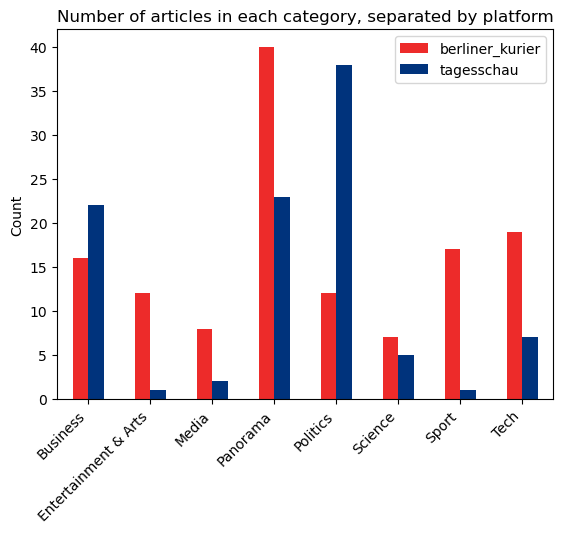

In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# assuming df is your DataFrame and 'category' and 'source' are your columns
grouped = platforms_df_vis.groupby(['category', 'source']).size().unstack()

#colors = ['firebrick', 'royalblue']
#colors = [(1, 0.2, 0.2), (0, 0, 0.7)]

ax=grouped.plot(kind='bar', color=["#ED2B2A", "#00337C"])

# Remove the legend title
legend = ax.get_legend()
legend.set_title('')

# Rotate labels by 45 degrees
plt.xticks(rotation=45, ha='right')  

# Adjust y-axis to show integer values
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Remove title from x-axis
ax.set_xlabel('')

plt.title('Number of articles in each category, separated by platform')
plt.ylabel('Count')
plt.show()


## 4.2 Percentage

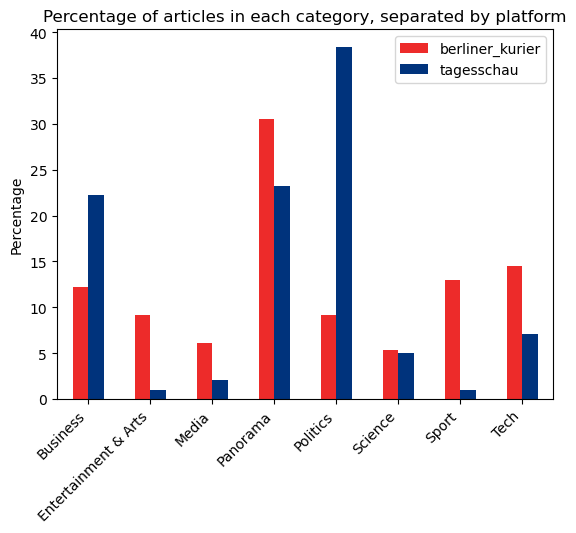

In [208]:
# assuming df is your DataFrame and 'class' and 'source' are your columns
source_counts = platforms_df_vis.groupby('source')['category'].count()
grouped = platforms_df_vis.groupby(['source', 'category']).size()
grouped_percentage = grouped.div(source_counts, level='source') * 100

grouped_percentage = grouped_percentage.reset_index().pivot(
    index='category', columns='source', values=0)

#colors = ['firebrick', 'royalblue']
colors = [(1, 0.2, 0.2), (0, 0, 0.7)]

ax=grouped_percentage.plot(kind='bar', color=["#ED2B2A", "#00337C"])

# Remove the legend title
legend = ax.get_legend()
legend.set_title('')

# Remove title from x-axis
ax.set_xlabel('')

# Rotate labels by 45 degrees
plt.xticks(rotation=45, ha='right')  

plt.title('Percentage of articles in each category, separated by platform')
plt.ylabel('Percentage')
plt.show()
